<center>
<a href="https://www.umontpellier.fr/"><img src="https://www.umontpellier.fr/wp-content/uploads/2022/10/logo_um_2022_rouge_rvb.svg" width="200"/></a>&nbsp;&nbsp;
<a href="https://economie.edu.umontpellier.fr/"><img src="https://economie.edu.umontpellier.fr/files/2014/12/economie_rvb_2015-300x137.png" width="160"/></a>
</center>

<div align="center">

#  Phase 1 — Nettoyage et Validation de la Base `dossier.csv`

| Nom et Prénom | Rôle |
|---|---|
| Randriamisaina Tsiory-Fanomezana | Membre de l'équipe |
| SHIRALI POUR Amir | Membre de l'équipe |

</div>

---
## Objectif de cette phase

Ce notebook constitue la **première phase** du pipeline de traitement des données.  
Il applique, dans l'ordre, toutes les corrections décrites dans [`docs/phase1_dossier.md`](../docs/phase1_dossier.md).

Pour chaque anomalie, la démarche est systématique :
1. **Constat** — quantification du problème
2. **Décision** — choix documenté avec justification métier/statistique  
3. **Action** — code de correction
4. **Vérification** — preuve que la correction est effective


---
## Section 0 — Initialisation

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Localisation de la racine du projet
def localiser_racine_du_projet():
    """Remonte l'arborescence jusqu'à trouver la racine du projet (présence de .git ou requirements.txt)."""
    repertoire_courant = Path.cwd()
    while True:
        if any((repertoire_courant / m).exists() for m in ['.git', 'requirements.txt']):
            break
        if repertoire_courant.parent == repertoire_courant:
            break
        repertoire_courant = repertoire_courant.parent
    if Path.cwd() != repertoire_courant:
        os.chdir(repertoire_courant)
    return repertoire_courant.resolve()

REPERTOIRE_RACINE = localiser_racine_du_projet()
sys.path.insert(0, str(REPERTOIRE_RACINE / 'src'))

from utils.dataframe_styler import style_duplicates
print(f" Racine du projet : {REPERTOIRE_RACINE}")

 Racine du projet : /Users/su6i/Documents/DU/Projet Data/projet_big_data_v2


In [2]:
# --- Chargement de la base brute
dossier_original = pd.read_csv('data/cleaned_dossier.csv', encoding='utf-8', sep=',', quotechar='"')

# Copie de travail — on ne touche JAMAIS à dossier_original
dossier = dossier_original.copy()

print(f" Dimensions chargées : {dossier.shape[0]:,} lignes × {dossier.shape[1]} colonnes")
print(f" Identifiants uniques : {dossier['Numero_dossier_ID'].nunique():,}")
print(f" Identifiants dupliqués : {dossier['Numero_dossier_ID'].duplicated().sum():,}")

 Dimensions chargées : 101,234 lignes × 17 colonnes
 Identifiants uniques : 100,000
 Identifiants dupliqués : 1,234


---
## Section 1 — Vue d'ensemble de la qualité des données

### 1.1 Types de données et valeurs non-nulles

In [3]:
dossier.info()

<class 'pandas.DataFrame'>
RangeIndex: 101234 entries, 0 to 101233
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype
---  ------                       --------------   -----
 0   Numero_dossier_ID            101234 non-null  int64
 1   Client                       101234 non-null  str  
 2   Formule                      100285 non-null  str  
 3   date.ouverture               101234 non-null  str  
 4   heure.ouverture              101234 non-null  str  
 5   Matricule.de.traitement      101234 non-null  int64
 6   Cause.intervention           100234 non-null  str  
 7   date.de.survenance           101234 non-null  str  
 8   Type.d.energie               100240 non-null  str  
 9   Outil.d.assistance           101234 non-null  str  
 10  Assistance.ou.Administratif  101234 non-null  str  
 11  TOP.D.R                      101234 non-null  int64
 12  TOP.VR                       101234 non-null  int64
 13  TOP.Rappat.valide            101234 non-

In [4]:
def compter_anomalies_par_colonne(dataframe):
    """
    Calcule, pour chaque colonne, le nombre de NaN, de '???', et le total.
    Retourne un DataFrame trié par anomalies décroissantes.
    """
    resultats = []
    for colonne in dataframe.columns:
        n_nan            = dataframe[colonne].isna().sum()
        n_interrogation  = (dataframe[colonne].astype(str).str.strip() == '???').sum()
        total_anomalies  = n_nan + n_interrogation
        pourcentage      = round(total_anomalies / len(dataframe) * 100, 2)
        resultats.append({
            'Colonne'        : colonne,
            'NaN'            : n_nan,
            "???"            : n_interrogation,
            'Total anomalies': total_anomalies,
            '% du total'     : pourcentage
        })
    return (pd.DataFrame(resultats)
              .sort_values('Total anomalies', ascending=False)
              .reset_index(drop=True))

tableau_anomalies_initial = compter_anomalies_par_colonne(dossier)
print("Tableau récapitulatif des anomalies (colonnes avec au moins 1 problème) :")
tableau_anomalies_initial[tableau_anomalies_initial['Total anomalies'] > 0]

Tableau récapitulatif des anomalies (colonnes avec au moins 1 problème) :


,Colonne,NaN,???,Total anomalies,% du total
0,Assistance.ou.Administratif,0,10000,10000,9.88
1,Formule,949,5000,5949,5.88
2,Cause.intervention,1000,0,1000,0.99
3,Type.d.energie,994,0,994,0.98


---
## Section 2 — Anomalie A1 : Doublons sur `Numero_dossier_ID`

### Constat
La base contient **101 234 lignes** mais seulement **100 000 identifiants uniques**,  
soit **1 234 lignes dupliquées**.

### Décision : Suppression — `keep='first'`
> `Numero_dossier_ID` est une **clé primaire** : chaque dossier doit apparaître exactement une fois.  
> Sans information supplémentaire permettant de distinguer la "bonne" occurrence,  
> on retient la **première** (convention standard en gestion de bases de données).  
> Cette approche préserve les 100 000 dossiers distincts sans perte d'information métier.

### 2.1 Identification et visualisation des doublons

In [5]:
masque_toutes_lignes_doublonnees = dossier.duplicated(subset=['Numero_dossier_ID'], keep=False)
lignes_doublonnees = dossier[masque_toutes_lignes_doublonnees].sort_values('Numero_dossier_ID')

print(f"Lignes impliquées dans des doublons : {masque_toutes_lignes_doublonnees.sum():,}")
print(f"Nombre d'IDs concernés              : {lignes_doublonnees['Numero_dossier_ID'].nunique():,}")
print()
print("Aperçu des 10 premières lignes dupliquées (groupes colorés par ID) :")
lignes_doublonnees.head(10).style_duplicates(id_column='Numero_dossier_ID')

Lignes impliquées dans des doublons : 2,468
Nombre d'IDs concernés              : 1,234

Aperçu des 10 premières lignes dupliquées (groupes colorés par ID) :


,Numero_dossier_ID,Client,Formule,date.ouverture,heure.ouverture,Matricule.de.traitement,Cause.intervention,date.de.survenance,Type.d.energie,Outil.d.assistance,Assistance.ou.Administratif,TOP.D.R,TOP.VR,TOP.Rappat.valide,TOP.Poursuite,TOP.Recup,TOP.Autres.Garanties
81904,5467339,C4,F4,2022/03/01,11:01:00,902,Panne mécanique,2022/03/01,Essence,Higgins,Assistance,0,0,0,0,0,0
75777,5467339,C4,F4,2022/03/01,11:01:00,902,Panne mécanique,2022/03/01,Essence,Higgins,Assistance,0,0,0,0,0,0
89530,5472326,C4,F4,2022/08/08,16:13:00,1619,Panne mécanique,2022/08/05,Diesel,MCS,Assistance,0,0,0,0,1,0
60555,5472326,C4,F4,2022/08/08,16:13:00,1619,Panne mécanique,2022/08/05,Diesel,MCS,Assistance,0,0,0,0,1,0
87646,5475528,C4,F23,2021/07/29,22:28:00,568,Panne mécanique,2021/07/29,Diesel,MCS,Assistance,1,0,0,0,0,0
41674,5475528,C4,F23,2021/07/29,22:28:00,568,Panne mécanique,2021/07/29,Diesel,MCS,Assistance,1,0,0,0,0,0
10856,5476073,C10,???,2021/01/20,11:34:00,171,Panne mécanique,2021/01/20,Autre,MCS,???,1,0,0,0,0,0
19873,5476073,C10,F119,2021/01/20,11:34:00,171,Panne mécanique,2021/01/20,Autre,MCS,Assistance,1,0,0,0,0,0
14662,5484073,C3,F3,2021/09/27,17:57:00,1610,"Clés, Carburant, Crevaison",2021/09/27,Diesel,MCS,Assistance,1,0,0,0,0,0
45293,5484073,C3,F3,2021/09/27,17:57:00,1610,"Clés, Carburant, Crevaison",2021/09/27,Diesel,MCS,Assistance,1,0,0,0,0,0


### 2.2 Suppression et vérification

In [6]:
nombre_lignes_avant_deduplication = len(dossier)

dossier.drop_duplicates(subset=['Numero_dossier_ID'], keep='first', inplace=True)
dossier.reset_index(drop=True, inplace=True)

nombre_lignes_apres_deduplication = len(dossier)
lignes_supprimees = nombre_lignes_avant_deduplication - nombre_lignes_apres_deduplication

print(f" {lignes_supprimees:,} lignes dupliquées supprimées")
print(f" Taille résultante : {nombre_lignes_apres_deduplication:,} lignes")

# Vérification formelle
assert dossier['Numero_dossier_ID'].duplicated().sum() == 0, " Des doublons subsistent !"
print(" Vérification : 0 doublon restant ")

 1,234 lignes dupliquées supprimées
 Taille résultante : 100,000 lignes
 Vérification : 0 doublon restant 


---
## Section 3 — Anomalies A2 & A3 : Formats et plages de dates

### 3.1 Anomalie A2 — Format français `DD/MM/YYYY` dans `date.ouverture` (10 lignes)

**Décision : Conversion vers le format ISO `YYYY/MM/DD`**  
> La date réelle est récupérable sans ambiguïté par `pd.to_datetime(..., dayfirst=True)`.  
> Le format ISO permet des comparaisons chronologiques directes en chaîne de caractères.

In [7]:
def convertir_date_vers_iso(valeur_date_en_chaine):
    """Convertit n'importe quel format de date parseable vers YYYY/MM/DD. Retourne la valeur originale si échec."""
    try:
        date_parsee = pd.to_datetime(valeur_date_en_chaine, dayfirst=True)
        return date_parsee.strftime('%Y/%m/%d')
    except Exception:
        return valeur_date_en_chaine

for colonne_date in ['date.ouverture', 'date.de.survenance']:
    valeurs_avant_conversion = dossier[colonne_date].copy()
    dossier[colonne_date]    = dossier[colonne_date].apply(convertir_date_vers_iso)
    masque_dates_modifiees   = valeurs_avant_conversion != dossier[colonne_date]
    print(f" {colonne_date} : {masque_dates_modifiees.sum():,} date(s) convertie(s) au format ISO")

/var/folders/gl/8xsjx1qs2dn1f0spl5xz6z480000gn/T/ipykernel_9683/3737220677.py:4: UserWarning: Parsing dates in %Y/%m/%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  date_parsee = pd.to_datetime(valeur_date_en_chaine, dayfirst=True)


 date.ouverture : 36,735 date(s) convertie(s) au format ISO


/var/folders/gl/8xsjx1qs2dn1f0spl5xz6z480000gn/T/ipykernel_9683/3737220677.py:4: UserWarning: Parsing dates in %Y/%m/%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  date_parsee = pd.to_datetime(valeur_date_en_chaine, dayfirst=True)


 date.de.survenance : 37,318 date(s) convertie(s) au format ISO


### 3.2 Anomalie A3 — Dates hors période 2021–2022

**Décision : Suppression de toutes les lignes hors `[2021/01/01 – 2022/12/31]`**  
> Le glossaire confirme que la base couvre exclusivement 2021–2022.  
> Les 10 dates `2020/01/01` (converties depuis `01/01/2020`) et les 1 000 dates `2023/01/01`  
> (issues de l'année seule `2023`) sont hors-scope et ne peuvent être corrigées sans données externes.  
> La valeur `2023` seule est également inutilisable pour toute analyse temporelle.

In [8]:
DATE_DEBUT_PERIODE = '2021/01/01'
DATE_FIN_PERIODE   = '2022/12/31'

masque_ouverture_hors_periode  = (
    (dossier['date.ouverture'] < DATE_DEBUT_PERIODE) |
    (dossier['date.ouverture'] > DATE_FIN_PERIODE)
)
masque_survenance_hors_periode = (
    (dossier['date.de.survenance'] < DATE_DEBUT_PERIODE) |
    (dossier['date.de.survenance'] > DATE_FIN_PERIODE)
)
masque_hors_periode_combine = masque_ouverture_hors_periode | masque_survenance_hors_periode

print(f"date.ouverture hors période    : {masque_ouverture_hors_periode.sum():,} ligne(s)")
print(f"date.de.survenance hors période: {masque_survenance_hors_periode.sum():,} ligne(s)")
print(f"Total à supprimer (union)      : {masque_hors_periode_combine.sum():,} ligne(s)")
print()
print("Échantillon des lignes hors période :")
dossier[masque_hors_periode_combine][
    ['Numero_dossier_ID','date.ouverture','date.de.survenance']
].head(10).style_duplicates(highlight_mask=masque_hors_periode_combine)

date.ouverture hors période    : 10 ligne(s)
date.de.survenance hors période: 1,056 ligne(s)
Total à supprimer (union)      : 1,065 ligne(s)

Échantillon des lignes hors période :


,Numero_dossier_ID,date.ouverture,date.de.survenance
1048,5762492,2021/12/18,2023/01/01
943,5913629,2021/04/29,2023/01/01
1132,6012685,2022/04/07,2023/01/01
1213,6386863,2022/11/14,2023/01/01
520,6517455,2021/04/23,2023/01/01
674,6858083,2022/12/12,2023/01/01
835,7081736,2021/04/12,2023/01/01
13,7418576,2022/09/20,2023/01/01
600,7980476,2022/10/11,2023/01/01
246,8478310,2021/04/12,2023/01/01


In [9]:
nombre_lignes_avant_suppression_dates = len(dossier)

dossier.drop(index=dossier[masque_hors_periode_combine].index, inplace=True)
dossier.reset_index(drop=True, inplace=True)

nombre_lignes_apres_suppression_dates = len(dossier)
print(f" {nombre_lignes_avant_suppression_dates - nombre_lignes_apres_suppression_dates:,} ligne(s) hors période supprimée(s)")
print(f" Taille résultante : {nombre_lignes_apres_suppression_dates:,} lignes")

# Vérification
n_hors_periode_restants = (
    (dossier['date.ouverture'] < DATE_DEBUT_PERIODE) | (dossier['date.ouverture'] > DATE_FIN_PERIODE) |
    (dossier['date.de.survenance'] < DATE_DEBUT_PERIODE) | (dossier['date.de.survenance'] > DATE_FIN_PERIODE)
).sum()
assert n_hors_periode_restants == 0, f" {n_hors_periode_restants} lignes hors période subsistent !"
print(" Vérification : 0 date hors période restante ")

 1,065 ligne(s) hors période supprimée(s)
 Taille résultante : 98,935 lignes
 Vérification : 0 date hors période restante 


---
## Section 4 — Anomalie A4 : Cohérence temporelle survenance / ouverture

### Constat
Un sinistre doit survenir **avant ou le jour même** de l'ouverture du dossier.  
Toute date de survenance postérieure à l'ouverture est une incohérence.

### Décision : Correction par substitution `date.de.survenance ← date.ouverture`
> On ne supprime pas la ligne car toutes ses autres informations sont exploitables.  
> On choisit la valeur la plus conservative : la date d'ouverture, qui est la borne haute certaine.

In [10]:
masque_survenance_superieure_a_ouverture = (
    dossier['date.de.survenance'] > dossier['date.ouverture']
)

print(f"Lignes avec survenance > ouverture : {masque_survenance_superieure_a_ouverture.sum():,}")

if masque_survenance_superieure_a_ouverture.sum() > 0:
    print()
    print("Aperçu avant correction :")
    dossier[masque_survenance_superieure_a_ouverture][
        ['Numero_dossier_ID','date.ouverture','date.de.survenance']
    ].head(5).style_duplicates(
        highlight_mask=masque_survenance_superieure_a_ouverture
    )

Lignes avec survenance > ouverture : 1,032

Aperçu avant correction :


In [11]:
dossier.loc[masque_survenance_superieure_a_ouverture, 'date.de.survenance'] = (
    dossier.loc[masque_survenance_superieure_a_ouverture, 'date.ouverture']
)

n_incoherences_restantes = (dossier['date.de.survenance'] > dossier['date.ouverture']).sum()
print(f" Correction appliquée : {masque_survenance_superieure_a_ouverture.sum():,} ligne(s) corrigée(s)")
print(f" Vérification : {n_incoherences_restantes} incohérence(s) restante(s) ")

 Correction appliquée : 1,032 ligne(s) corrigée(s)
 Vérification : 0 incohérence(s) restante(s) 


---
## Section 5 — Anomalie A5 : Heures invalides dans `heure.ouverture` (1 000 lignes)

### Constat
1 000 enregistrements contiennent `25:00:00` — une heure impossible (max `23:59:59`).

### Décision : Remplacement par `NaN`
> `25:00:00` est une **valeur sentinelle** signalant une heure non saisie.  
> On ne peut pas inférer l'heure réelle.  
> On conserve la ligne (les autres champs sont valides) et on marque l'heure comme manquante (`NaN`).

In [12]:
masque_heures_invalides = (
    ~pd.to_datetime(dossier['heure.ouverture'], format='%H:%M:%S', errors='coerce').notna()
    & dossier['heure.ouverture'].notna()
)

print(f"Heures invalides détectées : {masque_heures_invalides.sum():,}")
print(f"Valeur(s) concernée(s)     : {dossier[masque_heures_invalides]['heure.ouverture'].unique()}")
print()
print("Aperçu des lignes avec heure invalide (colonne heure surlignée en vert) :")
dossier[masque_heures_invalides][
    ['Numero_dossier_ID', 'date.ouverture', 'heure.ouverture', 'Matricule.de.traitement']
].head(5).style_duplicates(highlight_mask=masque_heures_invalides)

Heures invalides détectées : 978
Valeur(s) concernée(s)     : <ArrowStringArray>
['25:00:00']
Length: 1, dtype: str

Aperçu des lignes avec heure invalide (colonne heure surlignée en vert) :


,Numero_dossier_ID,date.ouverture,heure.ouverture,Matricule.de.traitement
184,5613807,2022/11/06,25:00:00,720
264,6395031,2021/03/23,25:00:00,581
27,6907008,2022/03/07,25:00:00,1151
6,7672949,2021/07/24,25:00:00,1086
265,8498028,2022/03/24,25:00:00,1375


In [13]:
dossier.loc[masque_heures_invalides, 'heure.ouverture'] = np.nan

n_heures_invalides_restantes = (
    ~pd.to_datetime(dossier['heure.ouverture'], format='%H:%M:%S', errors='coerce').notna()
    & dossier['heure.ouverture'].notna()
).sum()

print(f" {masque_heures_invalides.sum():,} heure(s) invalide(s) remplacée(s) par NaN")
print(f" Vérification : {n_heures_invalides_restantes} heure(s) invalide(s) restante(s) ")

 978 heure(s) invalide(s) remplacée(s) par NaN
 Vérification : 0 heure(s) invalide(s) restante(s) 


---
## Section 6 — Anomalie A6 : Valeurs `???` (données non renseignées)

### Constat

| Colonne | `???` | % du total |
|---------|-------|-----------|
| `Formule` | 5 000 | 5.0% |
| `Assistance.ou.Administratif` | 10 000 | 9.9% |

### Décision : Remplacement par `NaN`
> `???` est un **marqueur de substitution** utilisé lors de la collecte pour signaler une valeur inconnue.  
> Le conserver comme chaîne de caractères fausserait toutes les analyses (distributions, modèles).  
> On **ne supprime pas** les lignes : une perte de 5–10% des données serait excessive.  
> Le traitement par imputation est reporté à la phase de modélisation si nécessaire.

In [14]:
colonnes_avec_valeur_interrogation = ['Formule', 'Assistance.ou.Administratif']

for colonne in colonnes_avec_valeur_interrogation:
    nombre_interrogations_avant = (dossier[colonne] == '???').sum()
    
    # Affichage avant
    print(f"--- {colonne} : {nombre_interrogations_avant:,} valeurs '???' ---")
    dossier[dossier[colonne] == '???'][
        ['Numero_dossier_ID', 'Client', colonne]
    ].head(3).style_duplicates()
    
    # Remplacement
    dossier[colonne] = dossier[colonne].replace('???', np.nan)
    
    n_restantes = (dossier[colonne] == '???').sum()
    print(f" {nombre_interrogations_avant:,} '???' → NaN | {n_restantes} restante(s) ")
    print()

--- Formule : 4,908 valeurs '???' ---
 4,908 '???' → NaN | 0 restante(s) 

--- Assistance.ou.Administratif : 9,773 valeurs '???' ---
 9,773 '???' → NaN | 0 restante(s) 



---
## Section 7 — Anomalie A7 : Valeur `'inconnu'` dans `Type.d.energie`

### Constat
500 valeurs `'inconnu'` coexistent avec 994 `NaN`.

### Décision : Conservation de `'inconnu'` comme modalité distincte
> - `NaN` = donnée **absente** (non collectée, champ vide en entrée)  
> - `'inconnu'` = donnée **saisie volontairement** par l'opérateur : le type d'énergie n'est pas déterminable sur le terrain  
>
> Ces deux situations ont une **sémantique différente** et ne doivent pas être confondues.  
> `'inconnu'` est une information valide qui peut influencer les analyses.

In [15]:
print("Distribution complète de Type.d.energie :")
print(dossier['Type.d.energie'].value_counts(dropna=False).to_frame())
print()
print("→ 'inconnu' est conservé comme modalité catégorielle distincte de NaN.")

Distribution complète de Type.d.energie :
                count
Type.d.energie       
Diesel          53404
Essence         35061
Autre            4496
Hybride          2421
Electricité      1706
NaN               970
inconnu           494
GPL               383

→ 'inconnu' est conservé comme modalité catégorielle distincte de NaN.


---
## Section 8 — Anomalie A8 : Intégrité référentielle des matricules

### Constat
Chaque `Matricule.de.traitement` dans `dossier` devrait exister dans `ressources.csv`.

### Décision : Signalement sans suppression
> Un matricule orphelin peut indiquer un agent ayant quitté l'entreprise  
> (données historiques valides) ou une erreur de saisie.  
> Sans confirmation métier, la suppression est trop agressive.  
> Le problème est documenté pour investigation future.

In [16]:
ressources = pd.read_csv('data/ressources.csv', encoding='latin-1')

ensemble_matricules_dossier    = set(dossier['Matricule.de.traitement'].dropna().astype(int))
ensemble_matricules_ressources = set(ressources['Matricule'].dropna().astype(int))

matricules_orphelins = ensemble_matricules_dossier - ensemble_matricules_ressources
n_lignes_orphelines  = dossier[dossier['Matricule.de.traitement'].isin(matricules_orphelins)].shape[0]

print(f"Matricules dans dossier    : {len(ensemble_matricules_dossier):,}")
print(f"Matricules dans ressources : {len(ensemble_matricules_ressources):,}")
print(f"Matricules orphelins       : {len(matricules_orphelins)}")
print(f"Lignes concernées          : {n_lignes_orphelines:,}")

if matricules_orphelins:
    print(f"  Matricule(s) orphelin(s) : {sorted(matricules_orphelins)}")
    print("→ Signalé — à investiguer avec l'équipe métier")
else:
    print(" Aucun matricule orphelin — intégrité référentielle confirmée")

Matricules dans dossier    : 2,334
Matricules dans ressources : 2,507
Matricules orphelins       : 1
Lignes concernées          : 4,007
  Matricule(s) orphelin(s) : [171]
→ Signalé — à investiguer avec l'équipe métier


---
## Section 9 — Synthèse finale et tableau de bord

### 9.1 Bilan des transformations

In [17]:
bilan_transformations = pd.DataFrame([
    {'N°': 'A1', 'Anomalie': 'Identifiants dupliqués',             'Colonne': 'Numero_dossier_ID',          'N initial': 1234,  'Action appliquée': 'Suppression (keep=first)'},
    {'N°': 'A2', 'Anomalie': 'Format date français DD/MM/YYYY',    'Colonne': 'date.ouverture',              'N initial': 10,    'Action appliquée': 'Conversion ISO YYYY/MM/DD'},
    {'N°': 'A3', 'Anomalie': 'Dates hors période 2021–2022',       'Colonne': 'date.ouverture / survenance', 'N initial': 1010,  'Action appliquée': 'Suppression de la ligne'},
    {'N°': 'A4', 'Anomalie': 'Survenance postérieure à ouverture', 'Colonne': 'date.de.survenance',          'N initial': '?',   'Action appliquée': 'Correction → date.ouverture'},
    {'N°': 'A5', 'Anomalie': "Heure impossible (25:00:00)",         'Colonne': 'heure.ouverture',             'N initial': 1000,  'Action appliquée': 'Remplacement par NaN'},
    {'N°': 'A6', 'Anomalie': "Valeur '???' (non renseigné)",        'Colonne': 'Formule + Assistance',        'N initial': 15000, 'Action appliquée': 'Remplacement par NaN'},
    {'N°': 'A7', 'Anomalie': "Valeur 'inconnu' dans énergie",       'Colonne': 'Type.d.energie',              'N initial': 500,   'Action appliquée': 'Conservation (modalité valide)'},
    {'N°': 'A8', 'Anomalie': 'Matricule orphelin',                  'Colonne': 'Matricule.de.traitement',    'N initial': 1,     'Action appliquée': 'Signalé — investigation future'},
])
bilan_transformations

,N°,Anomalie,Colonne,N initial,Action appliquée
0,A1,Identifiants dupliqués,Numero_dossier_ID,1234,Suppression (keep=first)
1,A2,Format date français DD/MM/YYYY,date.ouverture,10,Conversion ISO YYYY/MM/DD
2,A3,Dates hors période 2021–2022,date.ouverture / survenance,1010,Suppression de la ligne
3,A4,Survenance postérieure à ouverture,date.de.survenance,?,Correction → date.ouverture
4,A5,Heure impossible (25:00:00),heure.ouverture,1000,Remplacement par NaN
5,A6,Valeur '???' (non renseigné),Formule + Assistance,15000,Remplacement par NaN
6,A7,Valeur 'inconnu' dans énergie,Type.d.energie,500,Conservation (modalité valide)
7,A8,Matricule orphelin,Matricule.de.traitement,1,Signalé — investigation future


### 9.2 État final des valeurs manquantes

In [18]:
valeurs_manquantes_finales = dossier.isna().sum()
valeurs_manquantes_finales = valeurs_manquantes_finales[valeurs_manquantes_finales > 0]

print(f" Dimensions finales : {dossier.shape[0]:,} lignes × {dossier.shape[1]} colonnes")
print(f"   (vs {len(dossier_original):,} lignes initialement — {len(dossier_original) - len(dossier):,} supprimées)")
print()
print("Valeurs manquantes restantes :")
df_manquants = pd.DataFrame({
    'Colonne': valeurs_manquantes_finales.index,
    'NaN restants': valeurs_manquantes_finales.values,
    '% du total': (valeurs_manquantes_finales.values / len(dossier) * 100).round(2)
})
df_manquants

 Dimensions finales : 98,935 lignes × 17 colonnes
   (vs 101,234 lignes initialement — 2,299 supprimées)

Valeurs manquantes restantes :


,Colonne,NaN restants,% du total
0,Formule,5834,5.90
1,heure.ouverture,978,0.99
2,Cause.intervention,973,0.98
3,Type.d.energie,970,0.98
4,Assistance.ou.Administratif,9773,9.88


### 9.3 Visualisation de la distribution finale

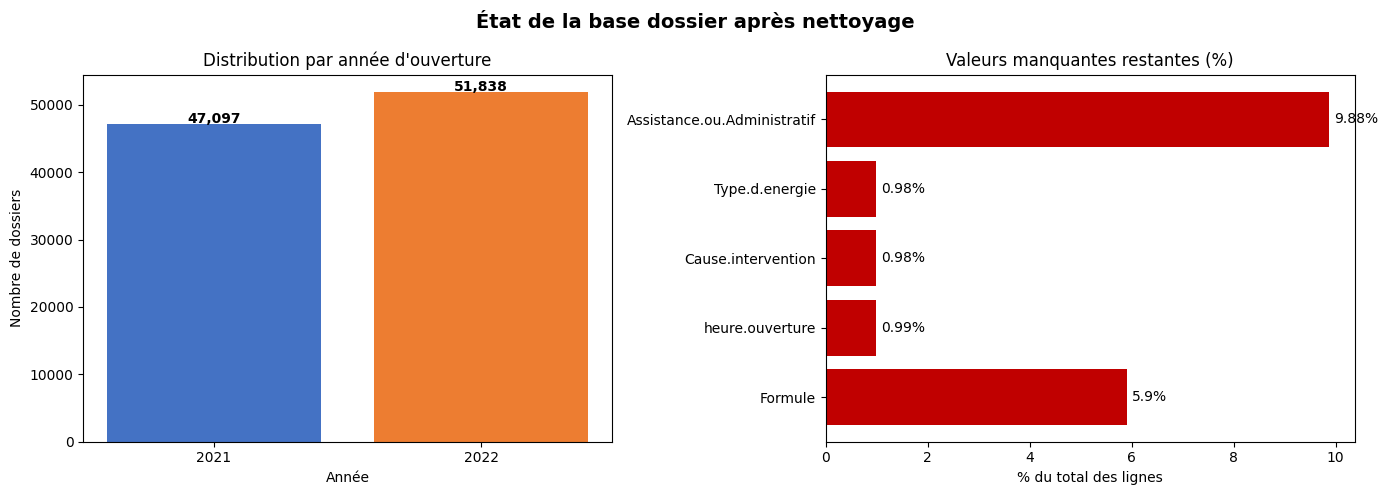

 Graphique sauvegardé : data/phase1_synthese_nettoyage.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("État de la base dossier après nettoyage", fontsize=14, fontweight='bold')

# Distribution par année
dossier['annee_ouverture'] = dossier['date.ouverture'].str[:4]
comptage_annees = dossier['annee_ouverture'].value_counts().sort_index()
axes[0].bar(comptage_annees.index, comptage_annees.values, color=['#4472c4', '#ed7d31'])
axes[0].set_title("Distribution par année d'ouverture")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre de dossiers")
for i, (annee, n) in enumerate(comptage_annees.items()):
    axes[0].text(i, n + 200, f"{n:,}", ha='center', fontweight='bold')

# Valeurs manquantes restantes
if len(valeurs_manquantes_finales) > 0:
    axes[1].barh(df_manquants['Colonne'], df_manquants['% du total'], color='#c00000')
    axes[1].set_title("Valeurs manquantes restantes (%)")
    axes[1].set_xlabel("% du total des lignes")
    for i, pct in enumerate(df_manquants['% du total']):
        axes[1].text(pct + 0.1, i, f"{pct}%", va='center')
else:
    axes[1].text(0.5, 0.5, "Aucune valeur" + chr(10) + "manquante !", ha='center', va='center',
                 fontsize=16, transform=axes[1].transAxes, color='green')
    axes[1].set_title("Valeurs manquantes restantes")

plt.tight_layout()
plt.savefig('data/phase1_synthese_nettoyage.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique sauvegardé : data/phase1_synthese_nettoyage.png")

---
## Section 10 — Export de la base nettoyée

In [20]:
CHEMIN_SORTIE = 'data/dossier_nettoye.csv'
dossier.drop(columns=['annee_ouverture'], errors='ignore', inplace=True)
dossier.to_csv(CHEMIN_SORTIE, index=False, encoding='utf-8')

print(f" Base nettoyée exportée : {CHEMIN_SORTIE}")
print(f"   {dossier.shape[0]:,} lignes × {dossier.shape[1]} colonnes")
print()
print("Aperçu des 5 premières lignes de la base finale :")
dossier.head(5).style_duplicates()

 Base nettoyée exportée : data/dossier_nettoye.csv
   98,935 lignes × 17 colonnes

Aperçu des 5 premières lignes de la base finale :


,Numero_dossier_ID,Client,Formule,date.ouverture,heure.ouverture,Matricule.de.traitement,Cause.intervention,date.de.survenance,Type.d.energie,Outil.d.assistance,Assistance.ou.Administratif,TOP.D.R,TOP.VR,TOP.Rappat.valide,TOP.Poursuite,TOP.Recup,TOP.Autres.Garanties
3,5630809,C7,F72,2021/08/11,19:46:00,1322,Panne mécanique,2021/08/11,Essence,MCS,Assistance,1,0,0,0,0,0
0,7494402,C5,F99,2021/11/02,10:38:00,326,Panne mécanique,2021/11/02,Diesel,MCS,Assistance,1,0,0,0,0,0
1,7569082,C4,F14,2022/12/07,18:40:00,1164,Panne mécanique,2022/12/07,Essence,MCS,nan,1,0,0,0,0,0
2,8111190,C0,F1,2021/08/01,12:32:00,1337,Panne mécanique,2021/08/01,Essence,MCS,Assistance,1,1,0,0,0,0
4,8179409,C4,F4,2021/11/08,18:12:00,2306,Panne mécanique,2021/11/08,Essence,Higgins,nan,1,0,0,0,0,0
